# Heat Diffusion Demo
Generates one graph + temperature trajectory, then animates.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from logic.graphon_generator import generate_constant_graphon, interp_graphon
from data.heat_dataset import HeatDiffusionDataset

In [ ]:
# 1. Build graphon and dataset
W = generate_constant_graphon(p=0.1, resolution=200)
graphon_fn = interp_graphon(W)
dataset = HeatDiffusionDataset(
    n_nodes=50,
    steps=100,
    alpha=0.1,
    graphon_fn=graphon_fn
)
# 2. Get one sample
traj = dataset[0].numpy()  # shape (T+1, N)

[[0.76435876 0.7965509  0.14601122 ... 0.25421634 0.59584856 0.40820882]
 [0.71229756 0.7300788  0.32827184 ... 0.43249577 0.6319829  0.54769343]
 [0.6775782  0.6686881  0.4170478  ... 0.518851   0.6312423  0.5820264 ]
 ...
 [0.55785865 0.5578165  0.5578144  ... 0.55971485 0.5581505  0.55824244]
 [0.5578714  0.5578306  0.5578288  ... 0.5596688  0.5581543  0.5582429 ]
 [0.55788374 0.5578442  0.55784273 ... 0.55962414 0.5581579  0.55824345]]


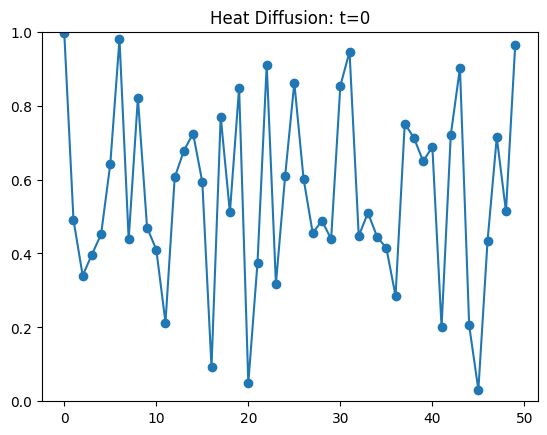

In [4]:
# 3. Animate
fig, ax = plt.subplots()
line, = ax.plot(traj[0], 'o-')
ax.set_ylim(0, 1)
ax.set_title('Heat Diffusion: t=0')

def update(frame):
    line.set_ydata(traj[frame])
    ax.set_title(f'Heat Diffusion: t={frame}')
    return line,

ani = animation.FuncAnimation(
    fig, update, frames=traj.shape[0], interval=100, blit=True
)
plt.show()